# Final Fingerprint Project (Colab Notebook)

This notebook processes fingerprint photos placed in the **`pic/`** folder.

It performs these steps for each image:

1. Read image  
2. Convert to grayscale  
3. Remove noise  
4. Enhance contrast  
5. Sharpen / clarify ridge lines  
6. Segment fingerprint region  
7. Apply Sobel edge detection  
8. Apply Canny edge detection  
9. Thin ridges to skeleton  
10. Detect simple minutiae candidates: ridge endings and bifurcations

**How to use**
- Open this notebook in Google Colab.
- Upload fingerprint photos into the `pic/` folder or use the upload cell.
- Run the cells from top to bottom.


In [ ]:
# Install required libraries
!pip install -q opencv-contrib-python matplotlib pillow numpy pandas
print("Libraries installed.")

In [1]:
# Imports
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

print("Imports loaded.")

Imports loaded.


In [2]:
# Folder settings
INPUT_DIR = "pic"
OUTPUT_DIR = "output"

os.makedirs(INPUT_DIR, exist_ok=True)
os.makedirs(OUTPUT_DIR, exist_ok=True)

print("Input folder:", os.path.abspath(INPUT_DIR))
print("Output folder:", os.path.abspath(OUTPUT_DIR))
print("Put your fingerprint photos inside the pic folder.")

Input folder: /Users/islomovic_j/Desktop/DIP_labs/final fingerprint/pic
Output folder: /Users/islomovic_j/Desktop/DIP_labs/final fingerprint/output
Put your fingerprint photos inside the pic folder.


In [3]:
# Optional upload helper for Google Colab
try:
    from google.colab import files
    IN_COLAB = True
except Exception:
    IN_COLAB = False

if IN_COLAB:
    print("Running in Colab.")
    print("Use the next cell if you want to upload files directly.")
else:
    print("Not running in Colab. You can still use local files in the pic folder.")

Not running in Colab. You can still use local files in the pic folder.


In [4]:
# Upload images directly in Colab (optional)
# After upload, files will be saved into the pic folder.

if IN_COLAB:
    uploaded = files.upload()
    for name, data in uploaded.items():
        save_path = os.path.join(INPUT_DIR, name)
        with open(save_path, "wb") as f:
            f.write(data)
    print("Uploaded files saved to pic/")
else:
    print("Skip this cell outside Colab.")

Skip this cell outside Colab.


In [5]:
# Helper functions

def show_image(title, image, cmap=None, figsize=(6, 6)):
    plt.figure(figsize=figsize)
    if image.ndim == 2:
        plt.imshow(image, cmap=cmap or "gray")
    else:
        plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
    plt.title(title)
    plt.axis("off")
    plt.show()


def resize_image(image, target_width=600):
    h, w = image.shape[:2]
    if w <= target_width:
        return image
    scale = target_width / float(w)
    new_h = int(h * scale)
    return cv2.resize(image, (target_width, new_h))


def crop_center_region(image, crop_ratio=0.85):
    h, w = image.shape[:2]
    ch = int(h * crop_ratio)
    cw = int(w * crop_ratio)
    y1 = max((h - ch) // 2, 0)
    x1 = max((w - cw) // 2, 0)
    return image[y1:y1+ch, x1:x1+cw]


def preprocess_fingerprint(image):
    steps = {}

    steps["01_original"] = image.copy()

    image = resize_image(image, target_width=600)
    steps["02_resized"] = image.copy()

    image = crop_center_region(image, crop_ratio=0.85)
    steps["03_cropped"] = image.copy()

    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    steps["04_grayscale"] = gray.copy()

    denoised = cv2.GaussianBlur(gray, (5, 5), 0)
    steps["05_denoised"] = denoised.copy()

    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
    enhanced = clahe.apply(denoised)
    steps["06_enhanced"] = enhanced.copy()

    sharpen_kernel = np.array([[0, -1, 0],
                               [-1, 5, -1],
                               [0, -1, 0]])
    sharpened = cv2.filter2D(enhanced, -1, sharpen_kernel)
    steps["07_sharpened"] = sharpened.copy()

    segmented_binary = cv2.adaptiveThreshold(
        sharpened,
        255,
        cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
        cv2.THRESH_BINARY_INV,
        15,
        5
    )
    steps["08_segmented_binary"] = segmented_binary.copy()

    kernel = np.ones((3, 3), np.uint8)
    cleaned = cv2.morphologyEx(segmented_binary, cv2.MORPH_OPEN, kernel)
    cleaned = cv2.morphologyEx(cleaned, cv2.MORPH_CLOSE, kernel)
    steps["09_cleaned"] = cleaned.copy()

    sobelx = cv2.Sobel(sharpened, cv2.CV_64F, 1, 0, ksize=3)
    sobely = cv2.Sobel(sharpened, cv2.CV_64F, 0, 1, ksize=3)
    sobel = cv2.magnitude(sobelx, sobely)
    sobel = np.uint8(np.clip(sobel, 0, 255))
    steps["10_sobel"] = sobel.copy()

    canny = cv2.Canny(sharpened, 50, 150)
    steps["11_canny"] = canny.copy()

    if hasattr(cv2, "ximgproc") and hasattr(cv2.ximgproc, "thinning"):
        skeleton = cv2.ximgproc.thinning(cleaned)
    else:
        skeleton = cleaned.copy()

    steps["12_skeleton"] = skeleton.copy()
    return steps


def detect_minutiae(skeleton):
    skel = (skeleton > 0).astype(np.uint8)
    minutiae_img = cv2.cvtColor(skeleton, cv2.COLOR_GRAY2BGR)

    endings = []
    bifurcations = []

    rows, cols = skel.shape

    for y in range(1, rows - 1):
        for x in range(1, cols - 1):
            if skel[y, x] == 1:
                neighborhood = skel[y-1:y+2, x-1:x+2]
                neighbors = int(np.sum(neighborhood)) - 1

                if neighbors == 1:
                    endings.append((x, y))
                elif neighbors >= 3:
                    bifurcations.append((x, y))

    for x, y in endings:
        cv2.circle(minutiae_img, (x, y), 2, (0, 255, 0), -1)

    for x, y in bifurcations:
        cv2.circle(minutiae_img, (x, y), 2, (0, 0, 255), -1)

    return minutiae_img, endings, bifurcations


def save_step_images(base_name, steps, minutiae_img):
    saved_dir = os.path.join(OUTPUT_DIR, base_name)
    os.makedirs(saved_dir, exist_ok=True)

    for step_name, img in steps.items():
        out_path = os.path.join(saved_dir, f"{step_name}.png")
        cv2.imwrite(out_path, img)

    cv2.imwrite(os.path.join(saved_dir, "13_minutiae.png"), minutiae_img)
    return saved_dir


print("Helper functions loaded successfully.")


Helper functions loaded successfully.


In [6]:
# Find images in the pic folder
valid_ext = (".png", ".jpg", ".jpeg", ".bmp", ".tif", ".tiff")
image_files = sorted([f for f in os.listdir(INPUT_DIR) if f.lower().endswith(valid_ext)])

print("Images found:", len(image_files))
for f in image_files:
    print("-", f)

if not image_files:
    print("No images found. Upload or place your fingerprint photos in the pic folder first.")

Images found: 7
- 1.jpg
- 2.jpg
- 3.jpg
- 4.jpg
- 5.jpg
- 6.jpg
- 7.jpg


In [7]:
# Process all images and save step-by-step outputs
results_summary = []

for file_name in image_files:
    file_path = os.path.join(INPUT_DIR, file_name)
    image = cv2.imread(file_path)

    if image is None:
        print("Could not read:", file_name)
        continue

    steps = preprocess_fingerprint(image)
    minutiae_img, endings, bifurcations = detect_minutiae(steps["12_skeleton"])

    base_name = os.path.splitext(file_name)[0]
    saved_dir = save_step_images(base_name, steps, minutiae_img)

    results_summary.append({
        "file": file_name,
        "ridge_endings": len(endings),
        "bifurcations": len(bifurcations),
        "saved_dir": saved_dir
    })

    print("=" * 70)
    print("Processed:", file_name)
    print("Saved to:", saved_dir)
    print("Ridge endings:", len(endings))
    print("Bifurcations:", len(bifurcations))


Processed: 1.jpg
Saved to: output/1
Ridge endings: 0
Bifurcations: 39557
Processed: 2.jpg
Saved to: output/2
Ridge endings: 0
Bifurcations: 70153
Processed: 3.jpg
Saved to: output/3
Ridge endings: 0
Bifurcations: 62732
Processed: 4.jpg
Saved to: output/4
Ridge endings: 0
Bifurcations: 58011
Processed: 5.jpg
Saved to: output/5
Ridge endings: 0
Bifurcations: 69877
Processed: 6.jpg
Saved to: output/6
Ridge endings: 0
Bifurcations: 40777
Processed: 7.jpg
Saved to: output/7
Ridge endings: 0
Bifurcations: 47946


Showing full pipeline for: 1.jpg


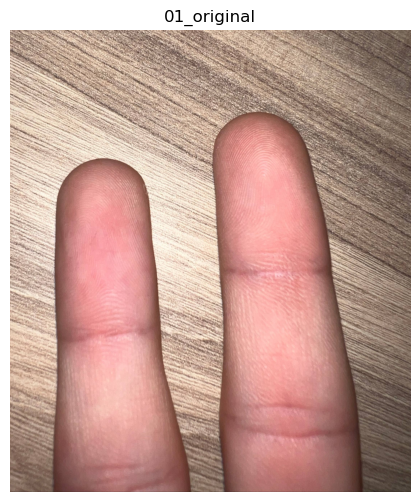

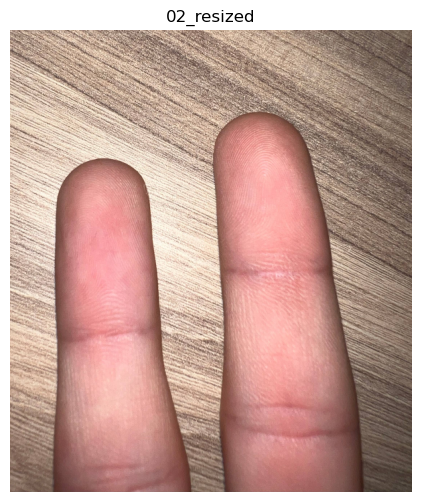

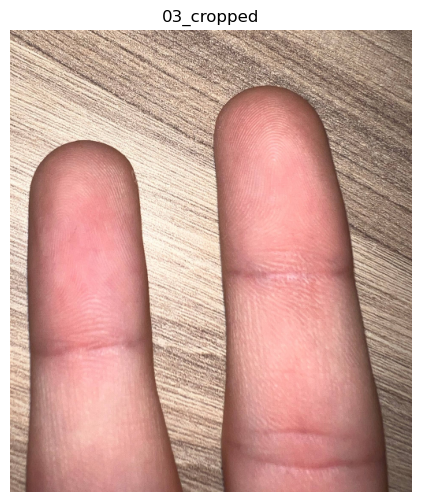

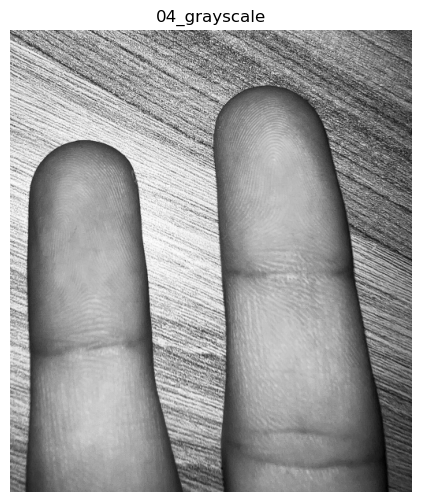

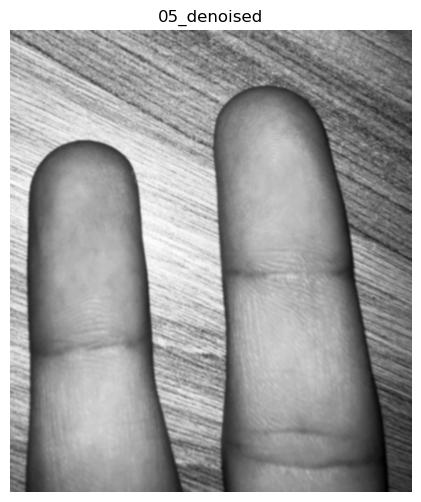

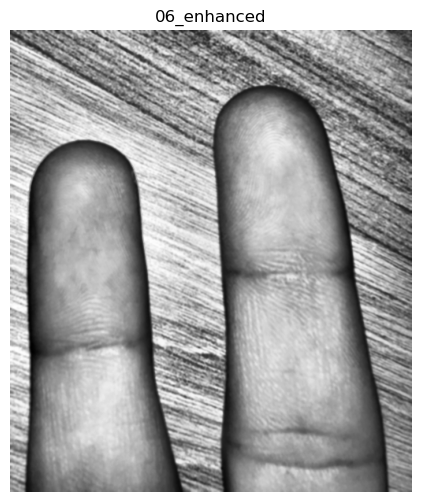

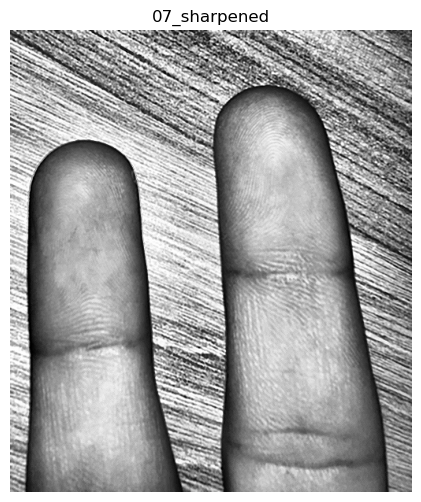

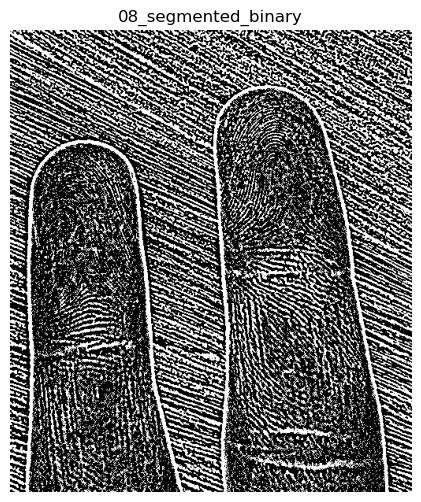

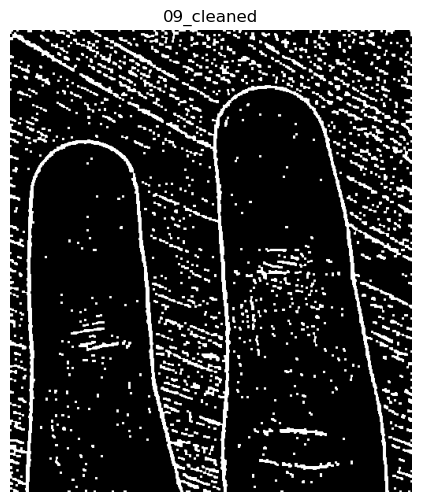

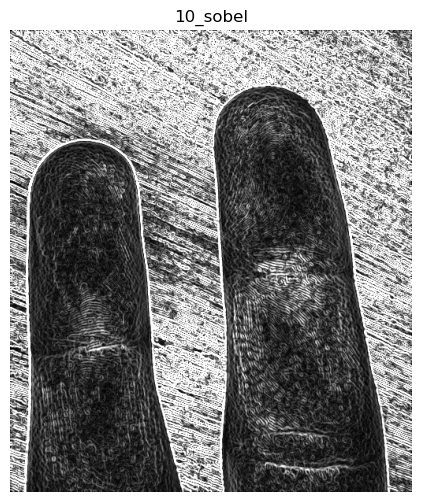

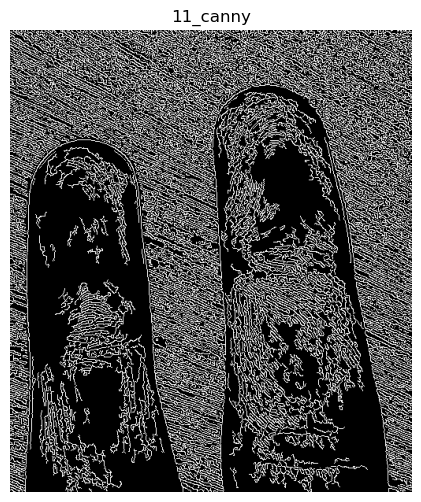

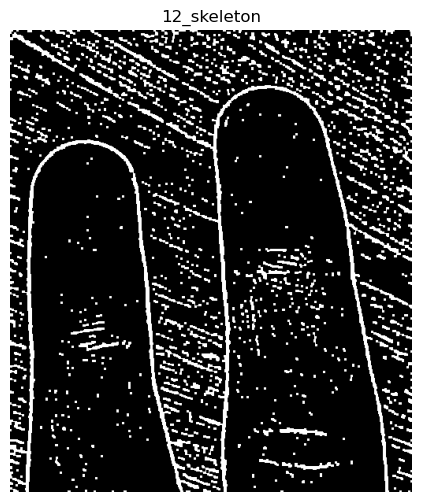

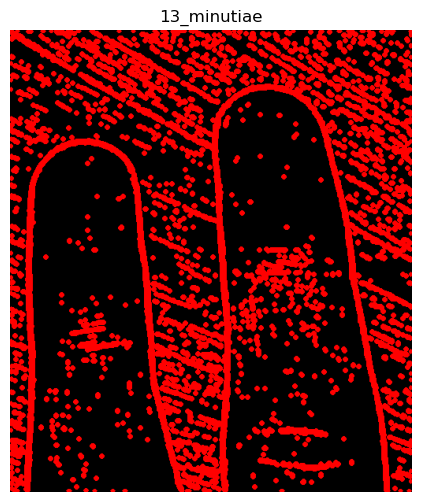

Ridge endings: 0
Bifurcations: 39557


In [8]:
# Show full step-by-step result for one selected image
if image_files:
    selected_file = image_files[0]   # Change index if you want another image
    print("Showing full pipeline for:", selected_file)

    image = cv2.imread(os.path.join(INPUT_DIR, selected_file))
    steps = preprocess_fingerprint(image)
    minutiae_img, endings, bifurcations = detect_minutiae(steps["12_skeleton"])

    for step_name, img in steps.items():
        show_image(step_name, img)

    show_image("13_minutiae", minutiae_img)
    print("Ridge endings:", len(endings))
    print("Bifurcations:", len(bifurcations))
else:
    print("No images available.")


In [9]:
# Show a compact summary table
if results_summary:
    df = pd.DataFrame(results_summary)
    display(df)
else:
    print("No processed results yet.")

,file,ridge_endings,bifurcations,saved_dir
0,1.jpg,0,39557,output/1
1,2.jpg,0,70153,output/2
2,3.jpg,0,62732,output/3
3,4.jpg,0,58011,output/4
4,5.jpg,0,69877,output/5
5,6.jpg,0,40777,output/6
6,7.jpg,0,47946,output/7


## Notes

- **Green dots** = ridge ending candidates  
- **Red dots** = bifurcation candidates  
- Because phone macro photos are not scanner-quality fingerprints, minutiae detection may include false points.
- Better lighting, focus, and closer crop usually improve results.
